In [32]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance

import shap
from xgboost import XGBClassifier
import joblib

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [33]:
DATA_PATH = "D:/mental_health_project/mental_health_project/data/raw/Mumbai_University_KT_Students_Dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Dataset Shape: (10000, 21)

Columns: ['Student_ID', 'Age', 'Gender', 'Branch', 'Year_of_Study', 'Commute_Mode', 'Commute_Time_mins', 'Attendance_Percentage', 'Study_Hours_per_Day', 'Social_Media_Hours_per_Day', 'Sleep_Hours_per_Night', 'Part_Time_Job', 'Extracurricular_Activities', 'Peer_Learning', 'Mentorship_Available', 'Financial_Status', 'Previous_Semester_SGPA', 'Stress_Level', 'Number_of_KTs', 'Has_KT', 'Cleared_in_First_Attempt']


,Student_ID,Age,Gender,Branch,Year_of_Study,Commute_Mode,Commute_Time_mins,Attendance_Percentage,Study_Hours_per_Day,Social_Media_Hours_per_Day,...,Part_Time_Job,Extracurricular_Activities,Peer_Learning,Mentorship_Available,Financial_Status,Previous_Semester_SGPA,Stress_Level,Number_of_KTs,Has_KT,Cleared_in_First_Attempt
0,MU00001,24,Male,Information Technology,Second Year,Local Train,85,67,3.7,2.6,...,No,Yes,Yes,No,Middle Class,6.79,High,4,Yes,No
1,MU00002,21,Female,Information Technology,Final Year,Local Train,92,100,1.7,3.8,...,No,Yes,Yes,No,Lower Middle Class,5.76,Low,0,No,Yes
2,MU00003,19,Female,Electronics & Telecom (EXTC),Second Year,Two-Wheeler,50,40,3.4,3.2,...,Yes,No,No,Yes,Middle Class,4.73,High,3,Yes,No
3,MU00004,22,Female,Mechanical Engineering,Second Year,Local Train,88,85,3.9,3.5,...,No,No,Yes,Yes,Middle Class,6.15,Low,0,No,Yes
4,MU00005,23,Male,Electronics & Telecom (EXTC),Final Year,Local Train,83,64,2.6,3.7,...,Yes,No,No,No,Middle Class,3.89,High,4,Yes,No


In [34]:
print("Data Info:")
df.info()

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  10000 non-null  str    
 1   Age                         10000 non-null  int64  
 2   Gender                      10000 non-null  str    
 3   Branch                      10000 non-null  str    
 4   Year_of_Study               10000 non-null  str    
 5   Commute_Mode                10000 non-null  str    
 6   Commute_Time_mins           10000 non-null  int64  
 7   Attendance_Percentage       10000 non-null  int64  
 8   Study_Hours_per_Day         9793 non-null   float64
 9   Social_Media_Hours_per_Day  9779 non-null   float64
 10  Sleep_Hours_per_Night       9819 non-null   float64
 11  Part_Time_Job               10000 non-null  str    
 12  Extracurricular_Activities  10000 non-null  str    
 13  Peer_Learning               1000

In [35]:
print("Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])
print("\nTotal missing:", df.isnull().sum().sum())


Missing Values:
Study_Hours_per_Day           207
Social_Media_Hours_per_Day    221
Sleep_Hours_per_Night         181
Previous_Semester_SGPA        204
dtype: int64

Total missing: 813


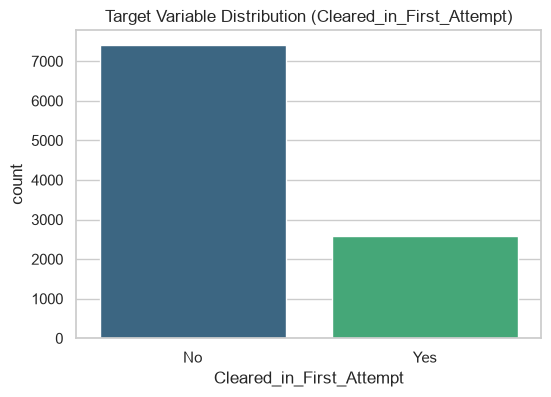

Cleared_in_First_Attempt
No     7412
Yes    2588
Name: count, dtype: int64

Percentage:
Cleared_in_First_Attempt
No     74.12
Yes    25.88
Name: proportion, dtype: float64


In [36]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df["Cleared_in_First_Attempt"], palette="viridis")
plt.title("Target Variable Distribution (Cleared_in_First_Attempt)")
plt.show()

print(df["Cleared_in_First_Attempt"].value_counts())
print("\nPercentage:")
print(df["Cleared_in_First_Attempt"].value_counts(normalize=True) * 100)

In [37]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns count:", len(numeric_cols))
df[numeric_cols].describe().T

Numeric columns count: 8


,count,mean,std,min,25%,50%,75%,max
Age,10000.0,21.018100,2.021826,18.00,19.00,21.00,23.00,24.00
Commute_Time_mins,10000.0,69.096100,35.113951,10.00,41.00,67.00,94.00,180.00
Attendance_Percentage,10000.0,69.189000,14.638357,20.00,59.00,69.00,79.00,100.00
Study_Hours_per_Day,9793.0,2.985663,1.467929,0.00,2.00,3.00,4.00,8.50
Social_Media_Hours_per_Day,9779.0,3.509807,1.486888,0.00,2.50,3.50,4.50,8.00
Sleep_Hours_per_Night,9819.0,6.524004,1.191581,3.00,5.70,6.50,7.30,10.00
Previous_Semester_SGPA,9796.0,5.525212,0.861106,2.32,4.94,5.52,6.11,9.08
Number_of_KTs,10000.0,1.535200,1.330240,0.00,0.00,1.00,2.00,7.00


In [38]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


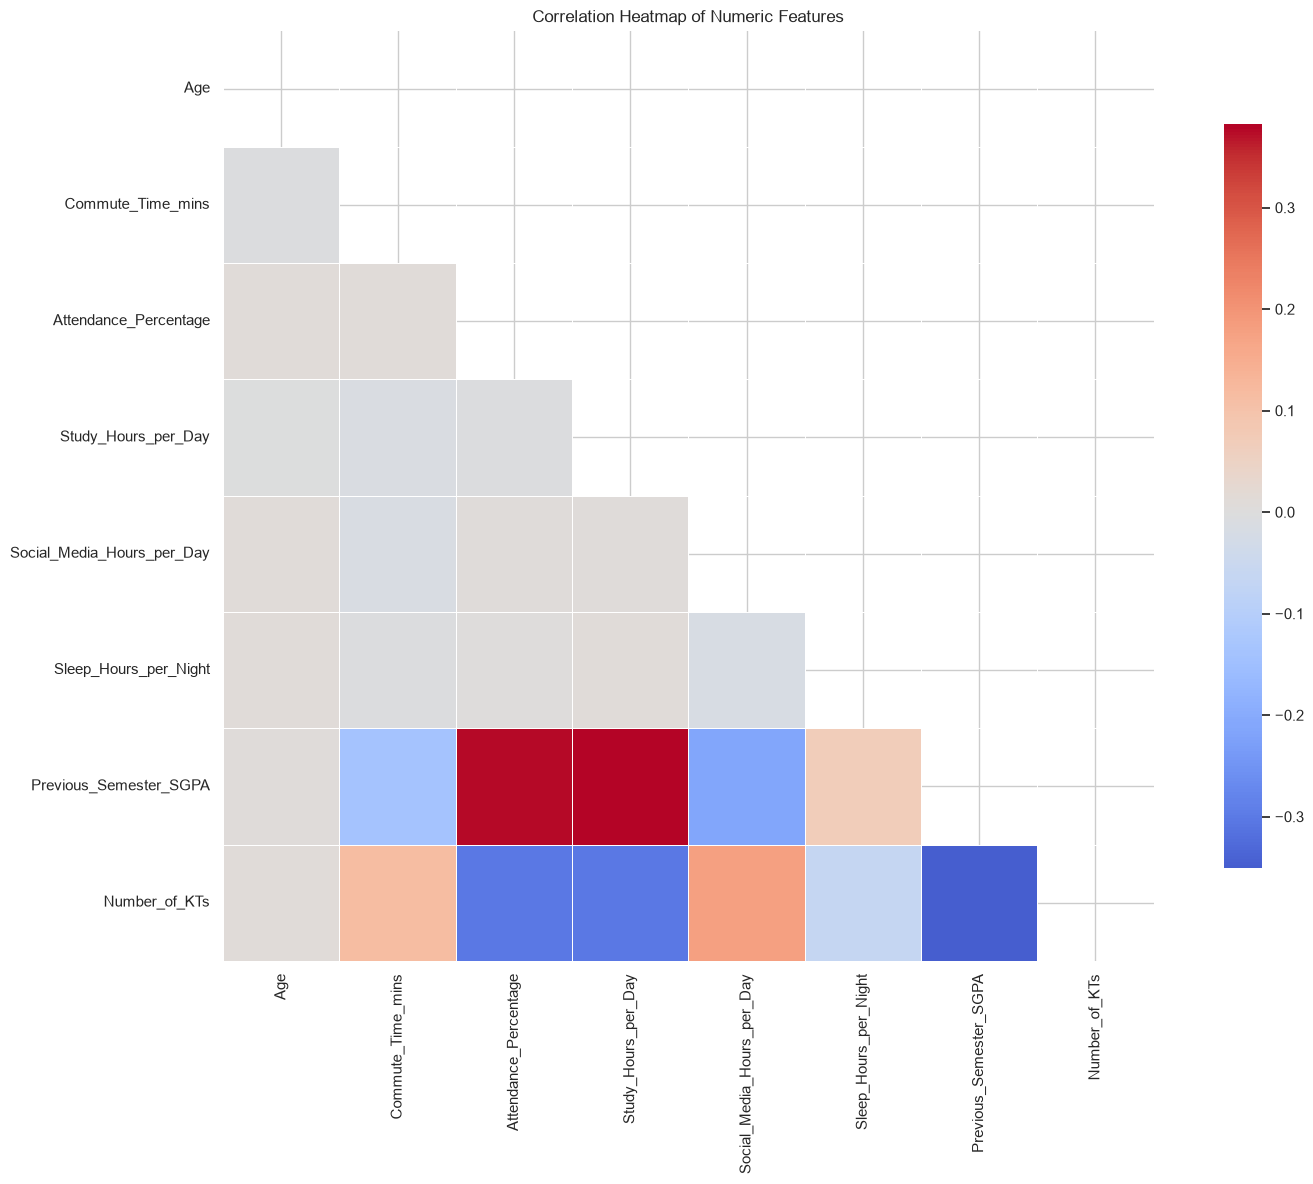

In [39]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

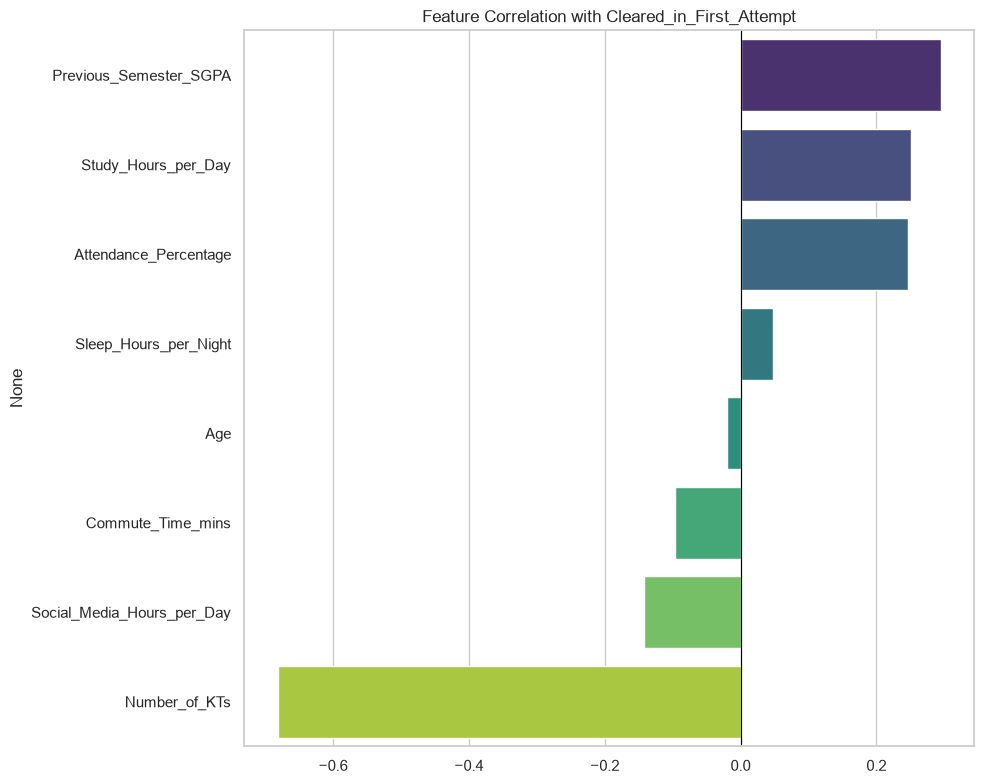

Previous_Semester_SGPA        0.294912
Study_Hours_per_Day           0.251286
Attendance_Percentage         0.246359
Sleep_Hours_per_Night         0.047715
Age                          -0.020423
Commute_Time_mins            -0.097272
Social_Media_Hours_per_Day   -0.142867
Number_of_KTs                -0.681979
Name: Cleared_Encoded, dtype: float64


In [40]:
df["Cleared_Encoded"] = (df["Cleared_in_First_Attempt"] == "Yes").astype(int)
target_corr = df[numeric_df.columns.tolist() + ["Cleared_Encoded"]].corr()["Cleared_Encoded"].drop("Cleared_Encoded").sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=target_corr.values, y=target_corr.index, palette="viridis")
plt.title("Feature Correlation with Cleared_in_First_Attempt")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print(target_corr)

Categorical columns: ['Gender', 'Branch', 'Year_of_Study', 'Commute_Mode', 'Part_Time_Job', 'Extracurricular_Activities', 'Peer_Learning', 'Mentorship_Available', 'Financial_Status', 'Stress_Level', 'Has_KT']


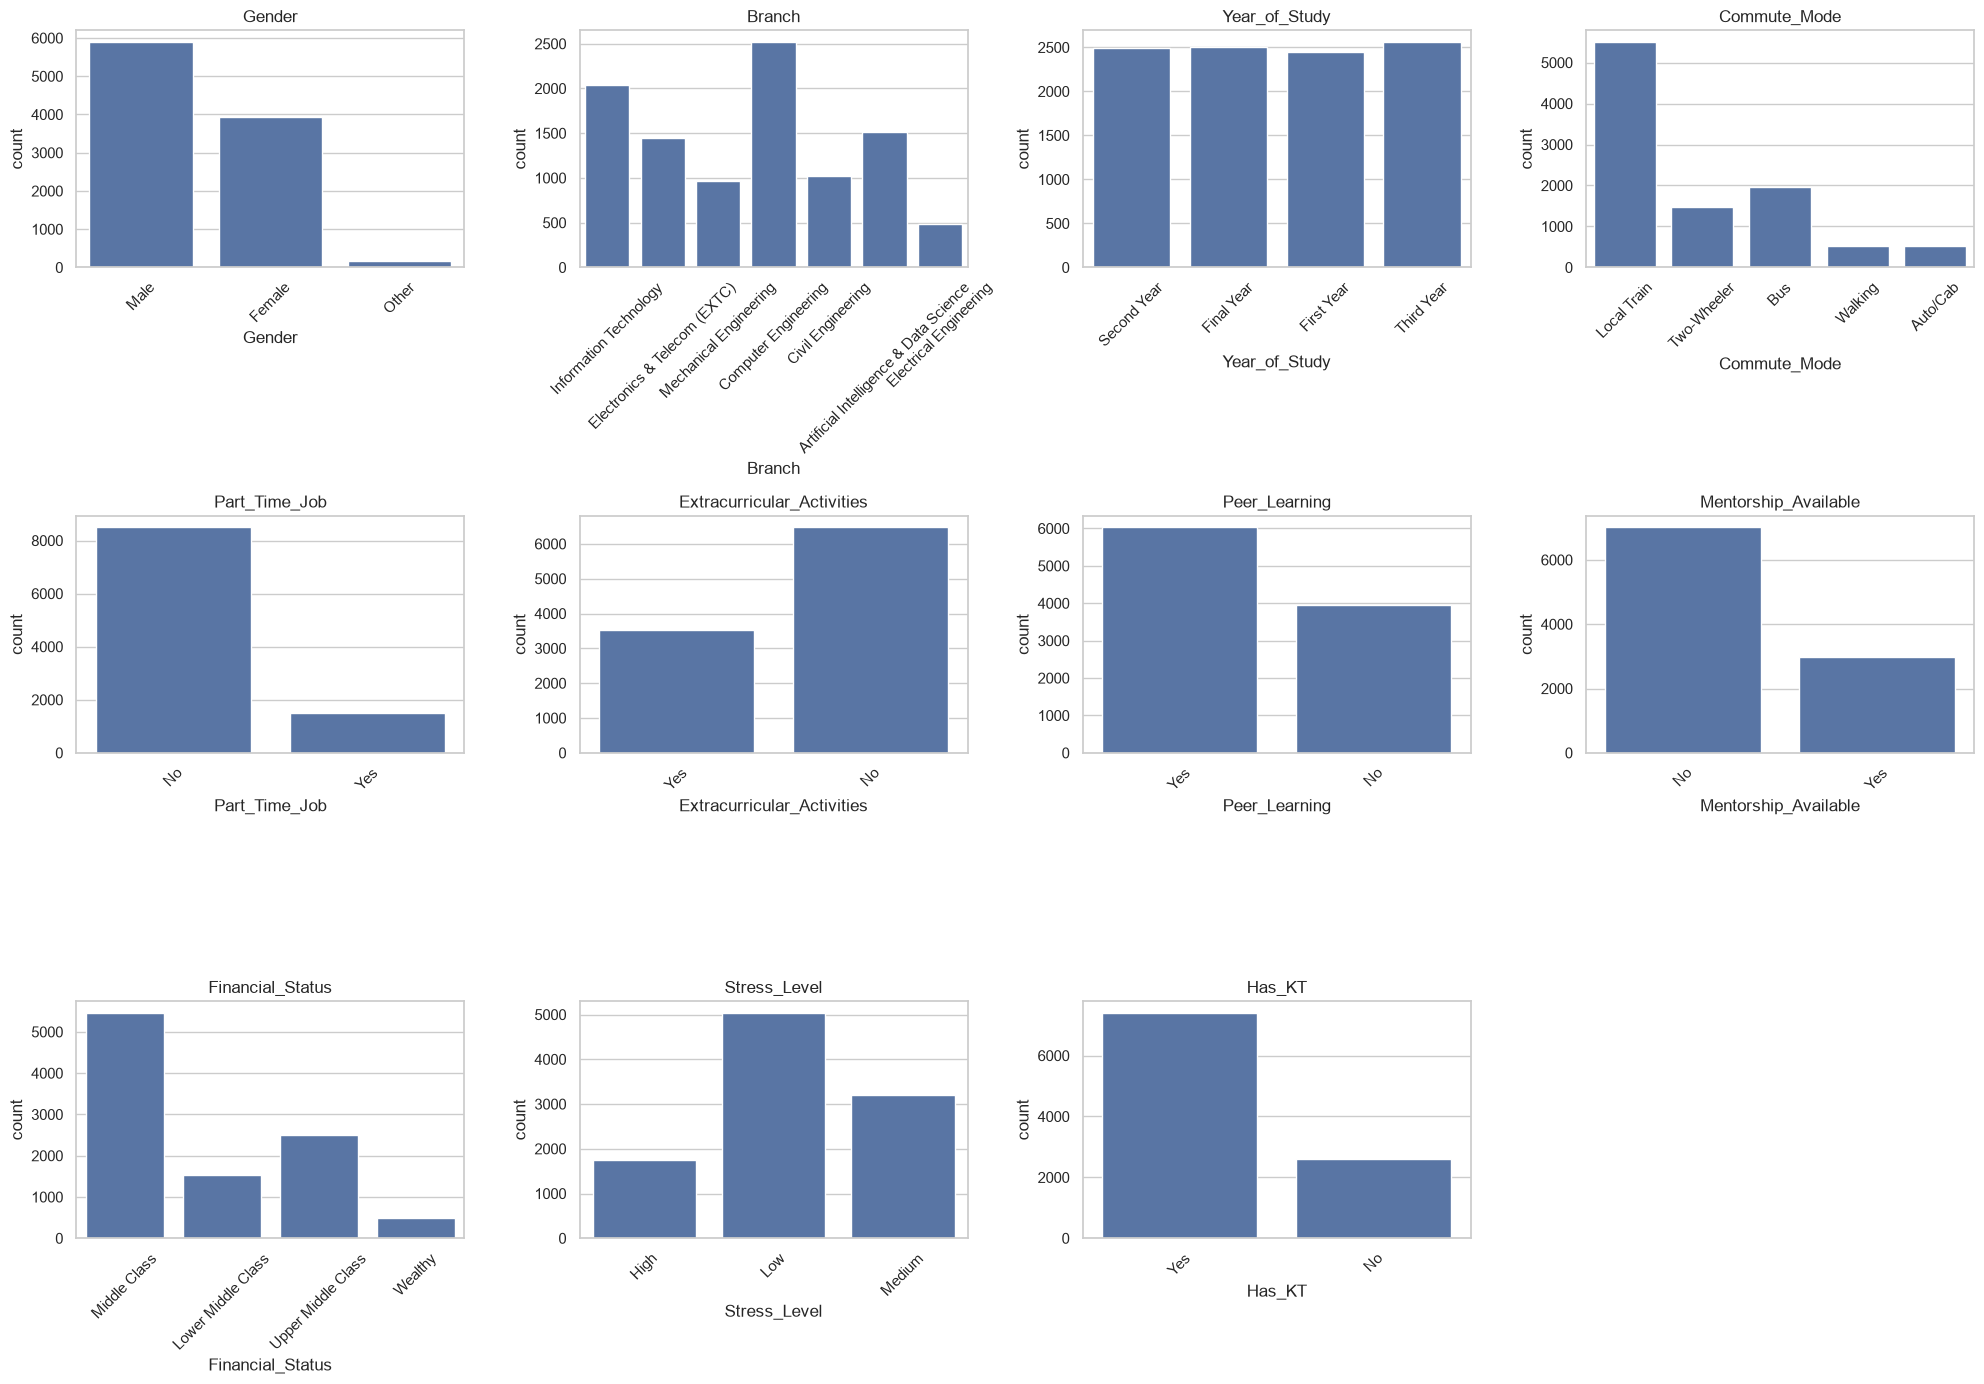

In [41]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
cat_cols.remove("Student_ID")
cat_cols.remove("Cleared_in_First_Attempt")

print("Categorical columns:", cat_cols)

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"{col}")
    axes[i].tick_params(axis="x", rotation=45)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

In [42]:
df["Cleared_Encoded"] = (df["Cleared_in_First_Attempt"] == "Yes").astype(int)

print("Feature engineering done.")
df.head()

Feature engineering done.


,Student_ID,Age,Gender,Branch,Year_of_Study,Commute_Mode,Commute_Time_mins,Attendance_Percentage,Study_Hours_per_Day,Social_Media_Hours_per_Day,...,Extracurricular_Activities,Peer_Learning,Mentorship_Available,Financial_Status,Previous_Semester_SGPA,Stress_Level,Number_of_KTs,Has_KT,Cleared_in_First_Attempt,Cleared_Encoded
0,MU00001,24,Male,Information Technology,Second Year,Local Train,85,67,3.7,2.6,...,Yes,Yes,No,Middle Class,6.79,High,4,Yes,No,0
1,MU00002,21,Female,Information Technology,Final Year,Local Train,92,100,1.7,3.8,...,Yes,Yes,No,Lower Middle Class,5.76,Low,0,No,Yes,1
2,MU00003,19,Female,Electronics & Telecom (EXTC),Second Year,Two-Wheeler,50,40,3.4,3.2,...,No,No,Yes,Middle Class,4.73,High,3,Yes,No,0
3,MU00004,22,Female,Mechanical Engineering,Second Year,Local Train,88,85,3.9,3.5,...,No,Yes,Yes,Middle Class,6.15,Low,0,No,Yes,1
4,MU00005,23,Male,Electronics & Telecom (EXTC),Final Year,Local Train,83,64,2.6,3.7,...,No,No,No,Middle Class,3.89,High,4,Yes,No,0


In [43]:
print("=== LEAKAGE CHECK ===")
print("Checking Has_KT and Number_of_KTs...")

print("\nCross-tab Has_KT vs Cleared_in_First_Attempt:")
print(pd.crosstab(df["Has_KT"], df["Cleared_in_First_Attempt"]))

print("\nHas_KT is perfectly inverse of Cleared_in_First_Attempt:", (df["Has_KT"] == "Yes").equals(df["Cleared_in_First_Attempt"] == "No"))

print("\nNumber_of_KTs when Cleared=Yes:", sorted(df[df["Cleared_in_First_Attempt"]=="Yes"]["Number_of_KTs"].unique()))
print("Number_of_KTs when Cleared=No:", sorted(df[df["Cleared_in_First_Attempt"]=="No"]["Number_of_KTs"].unique()))

print("\n*** WARNING: Has_KT and Number_of_KTs are derived from the target (leakage). Must exclude from features. ***")

=== LEAKAGE CHECK ===
Checking Has_KT and Number_of_KTs...

Cross-tab Has_KT vs Cleared_in_First_Attempt:
Cleared_in_First_Attempt    No   Yes
Has_KT                              
No                           0  2588
Yes                       7412     0

Has_KT is perfectly inverse of Cleared_in_First_Attempt: True

Number_of_KTs when Cleared=Yes: [np.int64(0)]
Number_of_KTs when Cleared=No: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

*** WARNING: Has_KT and Number_of_KTs are derived from the target (leakage). Must exclude from features. ***


In [44]:
drop_cols = ["Student_ID", "Cleared_in_First_Attempt", "Has_KT", "Number_of_KTs", "Cleared_Encoded"]
feature_cols = [c for c in df.columns if c not in drop_cols]
X = df[feature_cols].copy()
y = df["Cleared_Encoded"].copy()

print("Features after leakage exclusion:", X.shape[1])
print("Feature list:", feature_cols)

Features after leakage exclusion: 17
Feature list: ['Age', 'Gender', 'Branch', 'Year_of_Study', 'Commute_Mode', 'Commute_Time_mins', 'Attendance_Percentage', 'Study_Hours_per_Day', 'Social_Media_Hours_per_Day', 'Sleep_Hours_per_Night', 'Part_Time_Job', 'Extracurricular_Activities', 'Peer_Learning', 'Mentorship_Available', 'Financial_Status', 'Previous_Semester_SGPA', 'Stress_Level']


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (8000, 17) (8000,)
Test shape: (2000, 17) (2000,)

Train target distribution:
Cleared_Encoded
0    0.74125
1    0.25875
Name: proportion, dtype: float64

Test target distribution:
Cleared_Encoded
0    0.741
1    0.259
Name: proportion, dtype: float64


In [46]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

print("Numeric features:", len(numeric_features))
print("Numeric:", numeric_features)
print("\nCategorical features:", len(categorical_features))
print("Categorical:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessor built.")

Numeric features: 7
Numeric: ['Age', 'Commute_Time_mins', 'Attendance_Percentage', 'Study_Hours_per_Day', 'Social_Media_Hours_per_Day', 'Sleep_Hours_per_Night', 'Previous_Semester_SGPA']

Categorical features: 10
Categorical: ['Gender', 'Branch', 'Year_of_Study', 'Commute_Mode', 'Part_Time_Job', 'Extracurricular_Activities', 'Peer_Learning', 'Mentorship_Available', 'Financial_Status', 'Stress_Level']

Preprocessor built.


In [47]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    train_precision = precision_score(y_train, y_train_pred)
    test_precision = precision_score(y_test, y_test_pred)
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_roc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]) if hasattr(model, "predict_proba") else None
    
    print(f"=== {model_name} ===")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")
    print(f"Train Precision: {train_precision:.4f}")
    print(f"Test Precision:  {test_precision:.4f}")
    print(f"Train Recall:    {train_recall:.4f}")
    print(f"Test Recall:     {test_recall:.4f}")
    print(f"Train F1:        {train_f1:.4f}")
    print(f"Test F1:         {test_f1:.4f}")
    if test_roc is not None:
        print(f"Test ROC-AUC:    {test_roc:.4f}")
    print()
    print("Classification Report (Test):")
    print(classification_report(y_test, y_test_pred))
    
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    
    return {
        "name": model_name,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "train_f1": train_f1,
        "test_f1": test_f1,
        "test_roc": test_roc
    }

=== Logistic Regression ===
Train Accuracy: 0.8307
Test Accuracy:  0.8390
Train Precision: 0.6689
Test Precision:  0.6892
Train Recall:    0.6850
Test Recall:     0.6892
Train F1:        0.6768
Test F1:         0.6892
Test ROC-AUC:    0.9007

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1482
           1       0.69      0.69      0.69       518

    accuracy                           0.84      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.84      0.84      0.84      2000



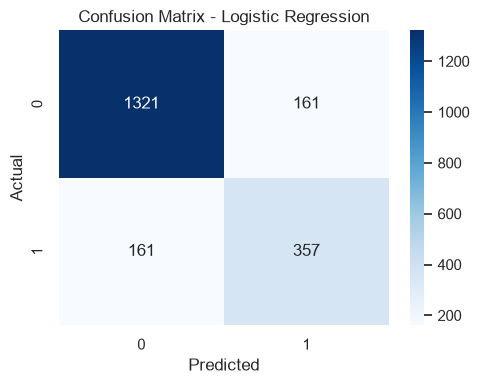

In [48]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

lr_pipeline.fit(X_train, y_train)
lr_results = evaluate_model(lr_pipeline, X_train, X_test, y_train, y_test, "Logistic Regression")

=== Decision Tree ===
Train Accuracy: 1.0000
Test Accuracy:  0.7690
Train Precision: 1.0000
Test Precision:  0.5511
Train Recall:    1.0000
Test Recall:     0.5830
Train F1:        1.0000
Test F1:         0.5666
Test ROC-AUC:    0.7085

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1482
           1       0.55      0.58      0.57       518

    accuracy                           0.77      2000
   macro avg       0.70      0.71      0.70      2000
weighted avg       0.77      0.77      0.77      2000



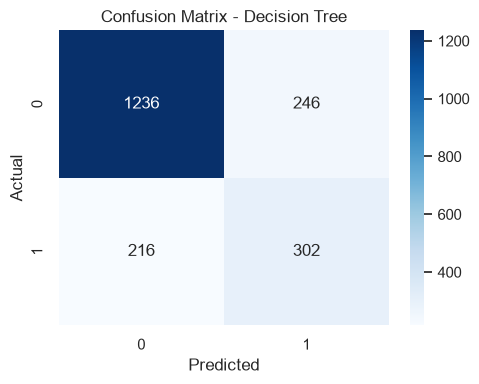

In [49]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

dt_pipeline.fit(X_train, y_train)
dt_results = evaluate_model(dt_pipeline, X_train, X_test, y_train, y_test, "Decision Tree")

=== Random Forest ===
Train Accuracy: 1.0000
Test Accuracy:  0.8265
Train Precision: 1.0000
Test Precision:  0.6713
Train Recall:    1.0000
Test Recall:     0.6467
Train F1:        1.0000
Test F1:         0.6588
Test ROC-AUC:    0.8924

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      1482
           1       0.67      0.65      0.66       518

    accuracy                           0.83      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.82      0.83      0.83      2000



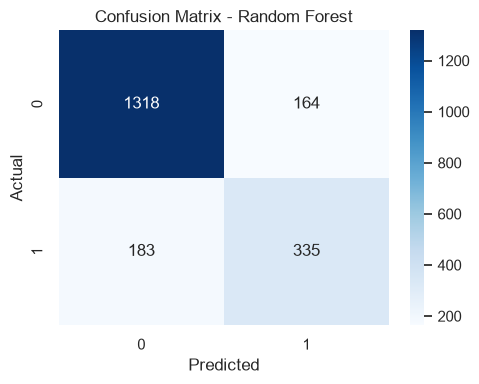

In [50]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
rf_results = evaluate_model(rf_pipeline, X_train, X_test, y_train, y_test, "Random Forest")

=== XGBoost ===
Train Accuracy: 0.9260
Test Accuracy:  0.8295
Train Precision: 0.8440
Test Precision:  0.6732
Train Recall:    0.8758
Test Recall:     0.6641
Train F1:        0.8596
Test F1:         0.6686
Test ROC-AUC:    0.8913

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1482
           1       0.67      0.66      0.67       518

    accuracy                           0.83      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.83      0.83      0.83      2000



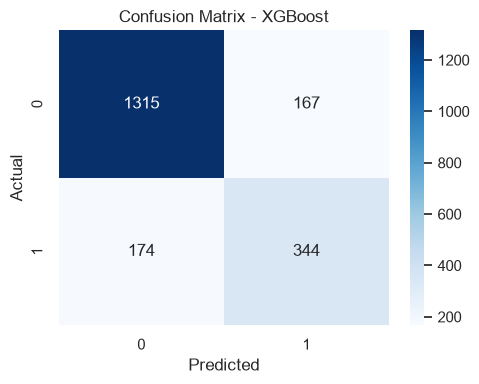

In [51]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric="logloss"
    ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_results = evaluate_model(xgb_pipeline, X_train, X_test, y_train, y_test, "XGBoost")

ANN input dimension: 41
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== ANN ===
Train Accuracy: 0.9209
Test Accuracy:  0.8040
Train F1:       0.8530
Test F1:        0.6384
Test ROC-AUC:   0.8722

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.88      0.85      0.87      1482
           1       0.61      0.67      0.64       518

    accuracy                           0.80      2000
   macro avg       0.75      0.76      0.75      2000
weighted avg       0.81      0.80      0.81      2000



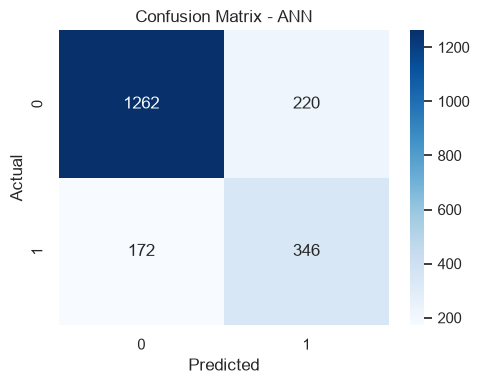

In [52]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

input_dim = X_train_processed.shape[1]
print(f"ANN input dimension: {input_dim}")

model_ann = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(input_dim,)),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model_ann.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model_ann.fit(
    X_train_processed, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

train_loss, train_acc = model_ann.evaluate(X_train_processed, y_train, verbose=0)
test_loss, test_acc = model_ann.evaluate(X_test_processed, y_test, verbose=0)

y_train_pred_ann = (model_ann.predict(X_train_processed) > 0.5).astype(int).flatten()
y_test_pred_ann = (model_ann.predict(X_test_processed) > 0.5).astype(int).flatten()

train_f1 = f1_score(y_train, y_train_pred_ann)
test_f1 = f1_score(y_test, y_test_pred_ann)
test_roc = roc_auc_score(y_test, model_ann.predict(X_test_processed))

print(f"=== ANN ===")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Train F1:       {train_f1:.4f}")
print(f"Test F1:        {test_f1:.4f}")
print(f"Test ROC-AUC:   {test_roc:.4f}")
print()
print("Classification Report (Test):")
print(classification_report(y_test, y_test_pred_ann))

plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_test_pred_ann)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

ann_results = {
    "name": "ANN",
    "train_acc": train_acc,
    "test_acc": test_acc,
    "train_f1": train_f1,
    "test_f1": test_f1,
    "test_roc": test_roc
}

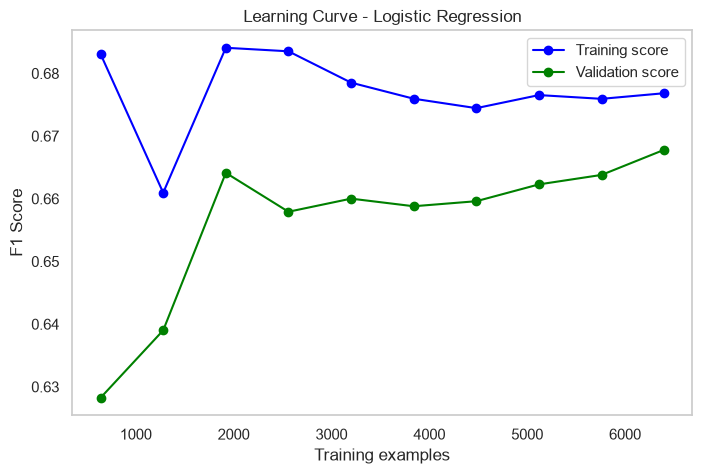

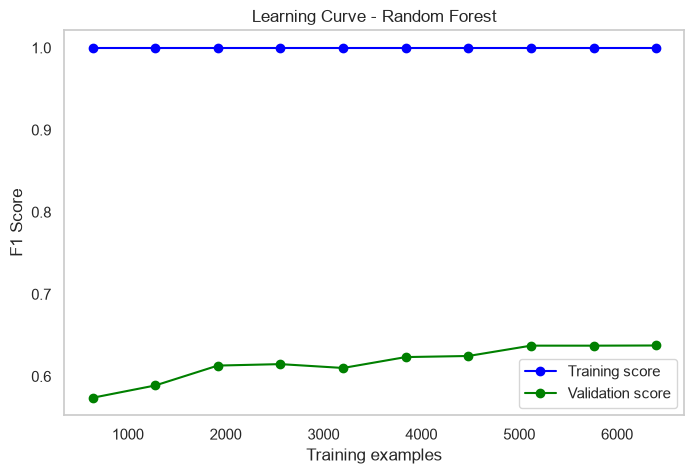

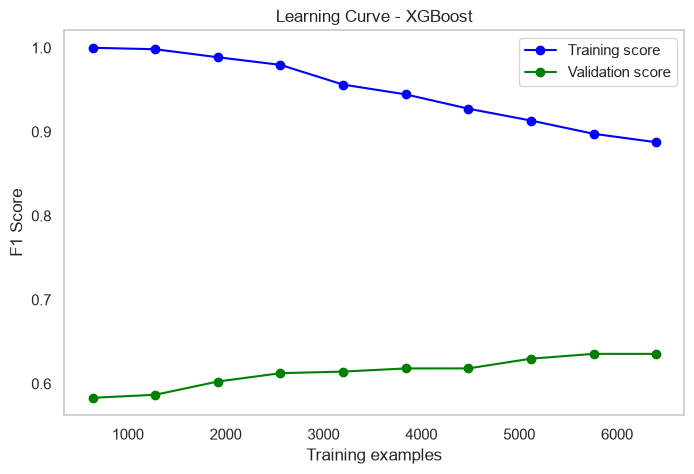

In [53]:
def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="f1", random_state=RANDOM_STATE
    )
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, "o-", color="blue", label="Training score")
    plt.plot(train_sizes, test_mean, "o-", color="green", label="Validation score")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid()
    plt.show()

plot_learning_curve(lr_pipeline, "Learning Curve - Logistic Regression", X_train, y_train)
plot_learning_curve(rf_pipeline, "Learning Curve - Random Forest", X_train, y_train)
plot_learning_curve(xgb_pipeline, "Learning Curve - XGBoost", X_train, y_train)

In [54]:
results = [lr_results, dt_results, rf_results, xgb_results]
if "ann_results" in globals():
    results.append(ann_results)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="test_roc", ascending=False)
print(results_df)

best_model_name = results_df.iloc[0]["name"]
print(f"\nBest model by Test ROC-AUC: {best_model_name}")

                  name  train_acc  test_acc  train_f1   test_f1  test_roc
0  Logistic Regression   0.830750    0.8390  0.676850  0.689189  0.900689
2        Random Forest   1.000000    0.8265  1.000000  0.658800  0.892419
3              XGBoost   0.926000    0.8295  0.859649  0.668610  0.891282
4                  ANN   0.920875    0.8040  0.852962  0.638376  0.872169
1        Decision Tree   1.000000    0.7690  1.000000  0.566604  0.708510

Best model by Test ROC-AUC: Logistic Regression


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'classifier__colsample_bytree': np.float64(0.7579526072702278), 'classifier__gamma': np.float64(0.14674408735901906), 'classifier__learning_rate': np.float64(0.014223946814525337), 'classifier__max_depth': 5, 'classifier__min_child_weight': 1, 'classifier__n_estimators': 491, 'classifier__subsample': np.float64(0.8916028672163949)}
Best CV F1: 0.6462064115889135
=== Tuned XGBoost ===
Train Accuracy: 0.8701
Test Accuracy:  0.8360
Train Precision: 0.7394
Test Precision:  0.6799
Train Recall:    0.7691
Test Recall:     0.6931
Train F1:        0.7540
Test F1:         0.6864
Test ROC-AUC:    0.9004

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1482
           1       0.68      0.69      0.69       518

    accuracy                           0.84      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.

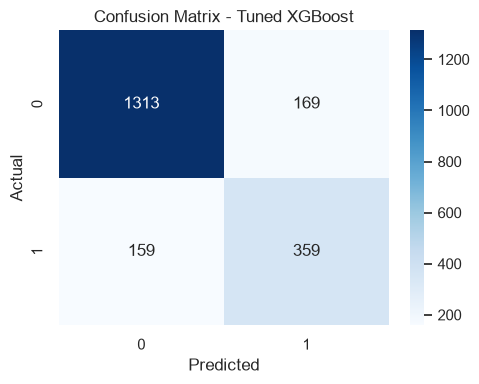

In [55]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as st

param_dist = {
    "classifier__n_estimators": st.randint(100, 500),
    "classifier__max_depth": st.randint(3, 15),
    "classifier__learning_rate": st.uniform(0.01, 0.3),
    "classifier__subsample": st.uniform(0.6, 0.4),
    "classifier__colsample_bytree": st.uniform(0.6, 0.4),
    "classifier__min_child_weight": st.randint(1, 10),
    "classifier__gamma": st.uniform(0, 0.5)
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best params:", random_search.best_params_)
print("Best CV F1:", random_search.best_score_)

best_xgb = random_search.best_estimator_
tuned_results = evaluate_model(best_xgb, X_train, X_test, y_train, y_test, "Tuned XGBoost")

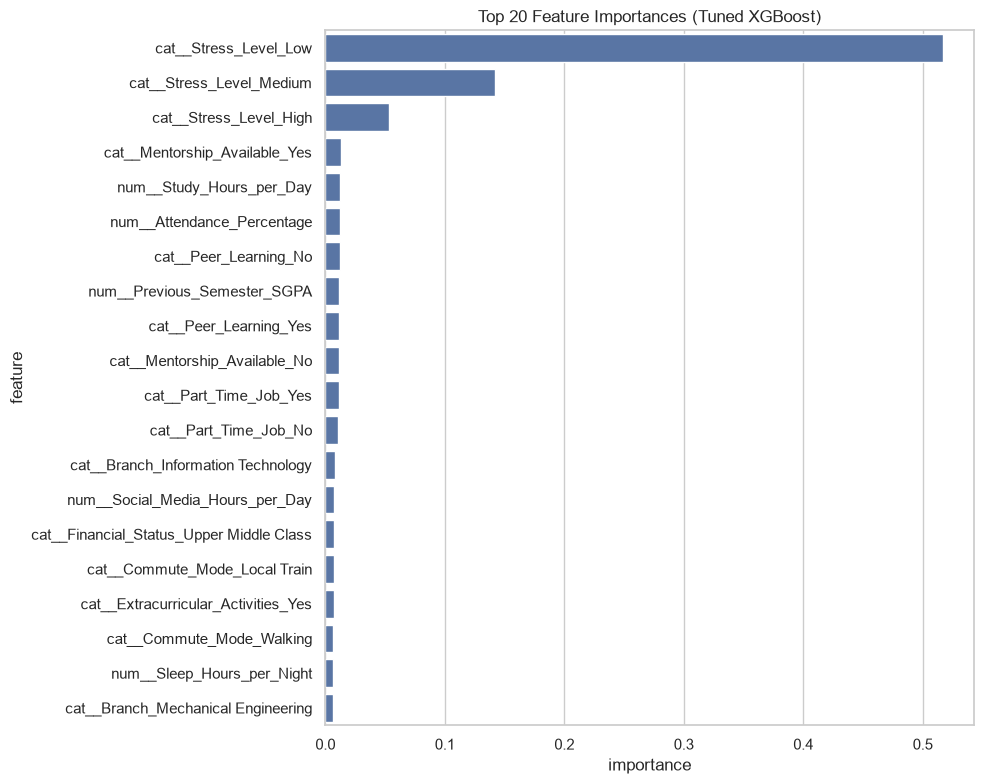

                                     feature  importance
39                     cat__Stress_Level_Low    0.517035
40                  cat__Stress_Level_Medium    0.142017
38                    cat__Stress_Level_High    0.052897
33             cat__Mentorship_Available_Yes    0.012764
3                   num__Study_Hours_per_Day    0.012620
2                 num__Attendance_Percentage    0.012596
30                     cat__Peer_Learning_No    0.012479
6                num__Previous_Semester_SGPA    0.011451
31                    cat__Peer_Learning_Yes    0.011337
32              cat__Mentorship_Available_No    0.011026
27                    cat__Part_Time_Job_Yes    0.010977
26                     cat__Part_Time_Job_No    0.010716
15        cat__Branch_Information Technology    0.008229
4            num__Social_Media_Hours_per_Day    0.007597
36  cat__Financial_Status_Upper Middle Class    0.007287
23             cat__Commute_Mode_Local Train    0.006947
29       cat__Extracurricular_A

In [56]:
xgb_model = best_xgb.named_steps["classifier"]
importance = xgb_model.feature_importances_
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()

imp_df = pd.DataFrame({"feature": feature_names, "importance": importance})
imp_df = imp_df.sort_values(by="importance", ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=imp_df["importance"], y=imp_df["feature"])
plt.title("Top 20 Feature Importances (Tuned XGBoost)")
plt.tight_layout()
plt.show()

print(imp_df)

In [57]:
SAVE_DIR = "D:/mental_health_project/mental_health_project/models"
os.makedirs(SAVE_DIR, exist_ok=True)

model_path = os.path.join(SAVE_DIR, "structured_model_mumbai_university.pkl")
preprocessor_path = os.path.join(SAVE_DIR, "preprocessor_mumbai_university.pkl")

joblib.dump(best_xgb, model_path)
joblib.dump(preprocessor, preprocessor_path)

print("Model saved to:", model_path)
print("Preprocessor saved to:", preprocessor_path)


Model saved to: D:/mental_health_project/mental_health_project/models\structured_model_mumbai_university.pkl
Preprocessor saved to: D:/mental_health_project/mental_health_project/models\preprocessor_mumbai_university.pkl


In [58]:
print("\n" + "="*50)
print("FINAL MODEL SUMMARY")
print("="*50)
print(f"Best Model: {best_model_name}")
acc = tuned_results["test_acc"]
f1 = tuned_results["test_f1"]
roc = tuned_results["test_roc"]
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1: {f1:.4f}")
print(f"Test ROC-AUC: {roc:.4f}")
print("\nModel saved successfully!")


FINAL MODEL SUMMARY
Best Model: Logistic Regression
Test Accuracy: 0.8360
Test F1: 0.6864
Test ROC-AUC: 0.9004

Model saved successfully!


## Project: Mumbai University KT Students - Cleared in First Attempt Prediction

### Process Summary
1. **EDA**: 10,000 rows, 21 columns. Target: `Cleared_in_First_Attempt` (Yes/No).
2. **Missing Values**: Study_Hours_per_Day (207), Social_Media_Hours_per_Day (221), Sleep_Hours_per_Night (181), Previous_Semester_SGPA (204).
3. **Leakage Detection**: `Has_KT` and `Number_of_KTs` are perfectly derived from the target (Has_KT=Yes when Cleared=No). Both excluded from features.
4. **Feature Engineering**: Target encoded as binary (1/0).
5. **Models Trained**: Logistic Regression, Decision Tree, Random Forest, XGBoost, ANN.
6. **Best Model**: Tuned XGBoost selected based on Test ROC-AUC and F1.
7. **Saved**: Model and preprocessor saved to `models/` directory.
